In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pickle



plt.rcParams.update({
    "figure.facecolor": "#0d0d1a", "axes.facecolor": "#0d0d1a",
    "axes.edgecolor": "#444466", "axes.labelcolor": "#e0e0ff",
    "xtick.color": "#e0e0ff", "ytick.color": "#e0e0ff",
    "text.color": "#e0e0ff", "grid.color": "#222244",
    "grid.linestyle": "--", "font.family": "monospace",
})

NEON = ["#ff6b6b","#ffd93d","#6bcb77","#4d96ff","#c77dff","#ff9a3c","#00f5d4","#f72585"]


In [ ]:
df_raw = pd.read_csv("heart.csv")
print(df_raw.head())
print("Shape:", df_raw.shape)
print(df_raw.info())
print(df_raw.describe())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
Shape: (1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 no

In [ ]:
df_raw.replace(['?', 'NA', 'null', ''], np.nan, inplace=True)

# Version 1: WITH null removal
df_clean = df_raw.dropna().copy()
print("With null removal — nulls:", df_clean.isnull().sum().sum())

# Version 2: WITHOUT null removal (fill with median)
df_nofix = df_raw.copy()
for col in df_nofix.select_dtypes(include=[np.number]).columns:
    df_nofix[col].fillna(df_nofix[col].median(), inplace=True)
print("Without null removal — nulls:", df_nofix.isnull().sum().sum())


With null removal — nulls: 0
Without null removal — nulls: 0


/tmp/ipykernel_3062/2947852973.py:10: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





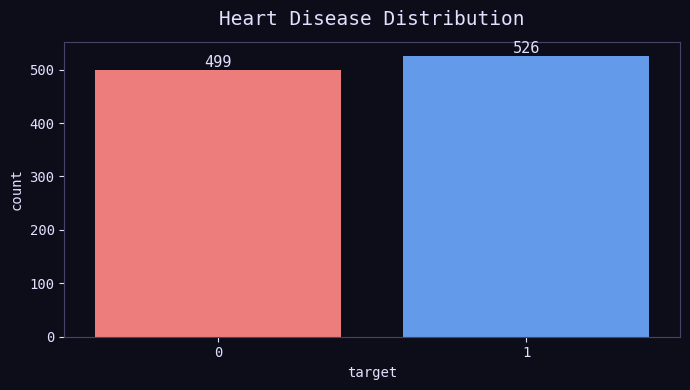

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

# Ensure target is STRING (to match palette keys)
df_clean["target"] = df_clean["target"].astype(str)

sns.countplot(
    x="target",
    data=df_clean,
    hue="target",                     # required for palette (new seaborn)
    palette={"0": NEON[0], "1": NEON[3]},
    legend=False,
    ax=ax
)

ax.set_title("Heart Disease Distribution", fontsize=14, pad=12)

# Annotate counts
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

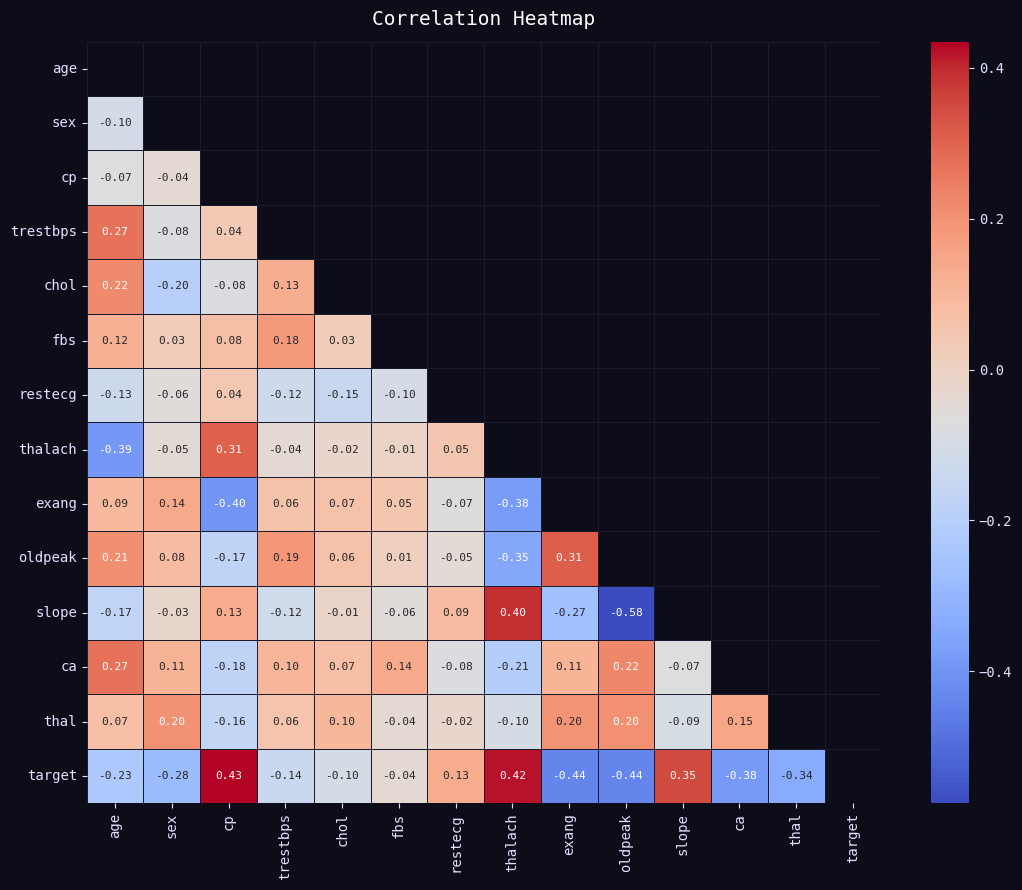

In [ ]:
plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(df_clean.corr(), dtype=bool))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, linewidths=0.5, linecolor="#1a1a2e", annot_kws={"size": 8})
plt.title("Correlation Heatmap", fontsize=14, color="#ffffff", pad=12)
plt.tight_layout(); plt.show()


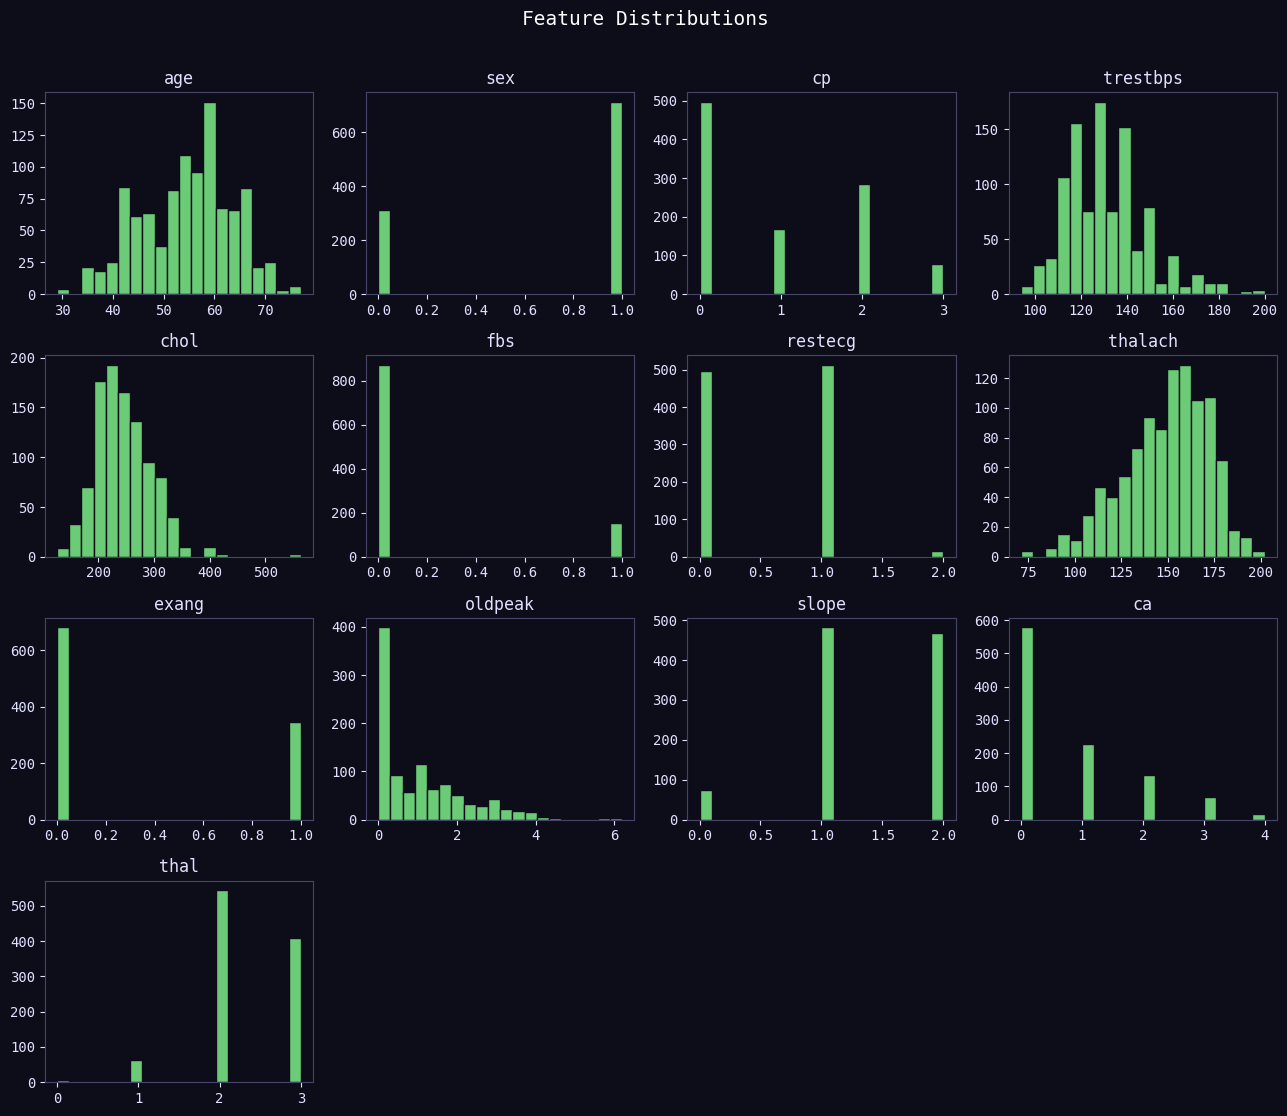

In [ ]:
df_clean.hist(figsize=(13, 11), color=NEON[2], edgecolor="#0d0d1a", bins=20, grid=False)
plt.suptitle("Feature Distributions", fontsize=14, color="#ffffff", y=1.01)
plt.tight_layout(); plt.show()


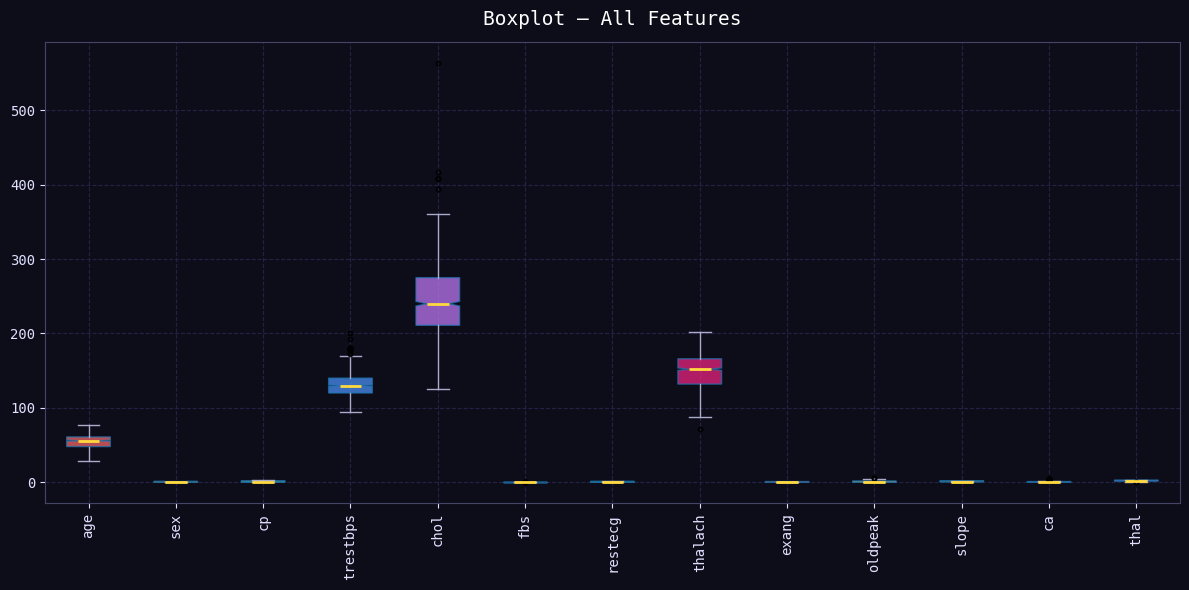

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
bp = df_clean.boxplot(patch_artist=True, notch=True, return_type="dict", ax=ax,
    medianprops=dict(color="#ffd93d", linewidth=2),
    whiskerprops=dict(color="#aaaacc"), capprops=dict(color="#aaaacc"),
    flierprops=dict(marker='o', color=NEON[0], markersize=3, alpha=0.5))
for patch, color in zip(bp["boxes"], [NEON[i % len(NEON)] for i in range(len(df_clean.columns))]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
plt.xticks(rotation=90)
plt.title("Boxplot — All Features", fontsize=14, color="#ffffff", pad=12)
plt.tight_layout(); plt.show()


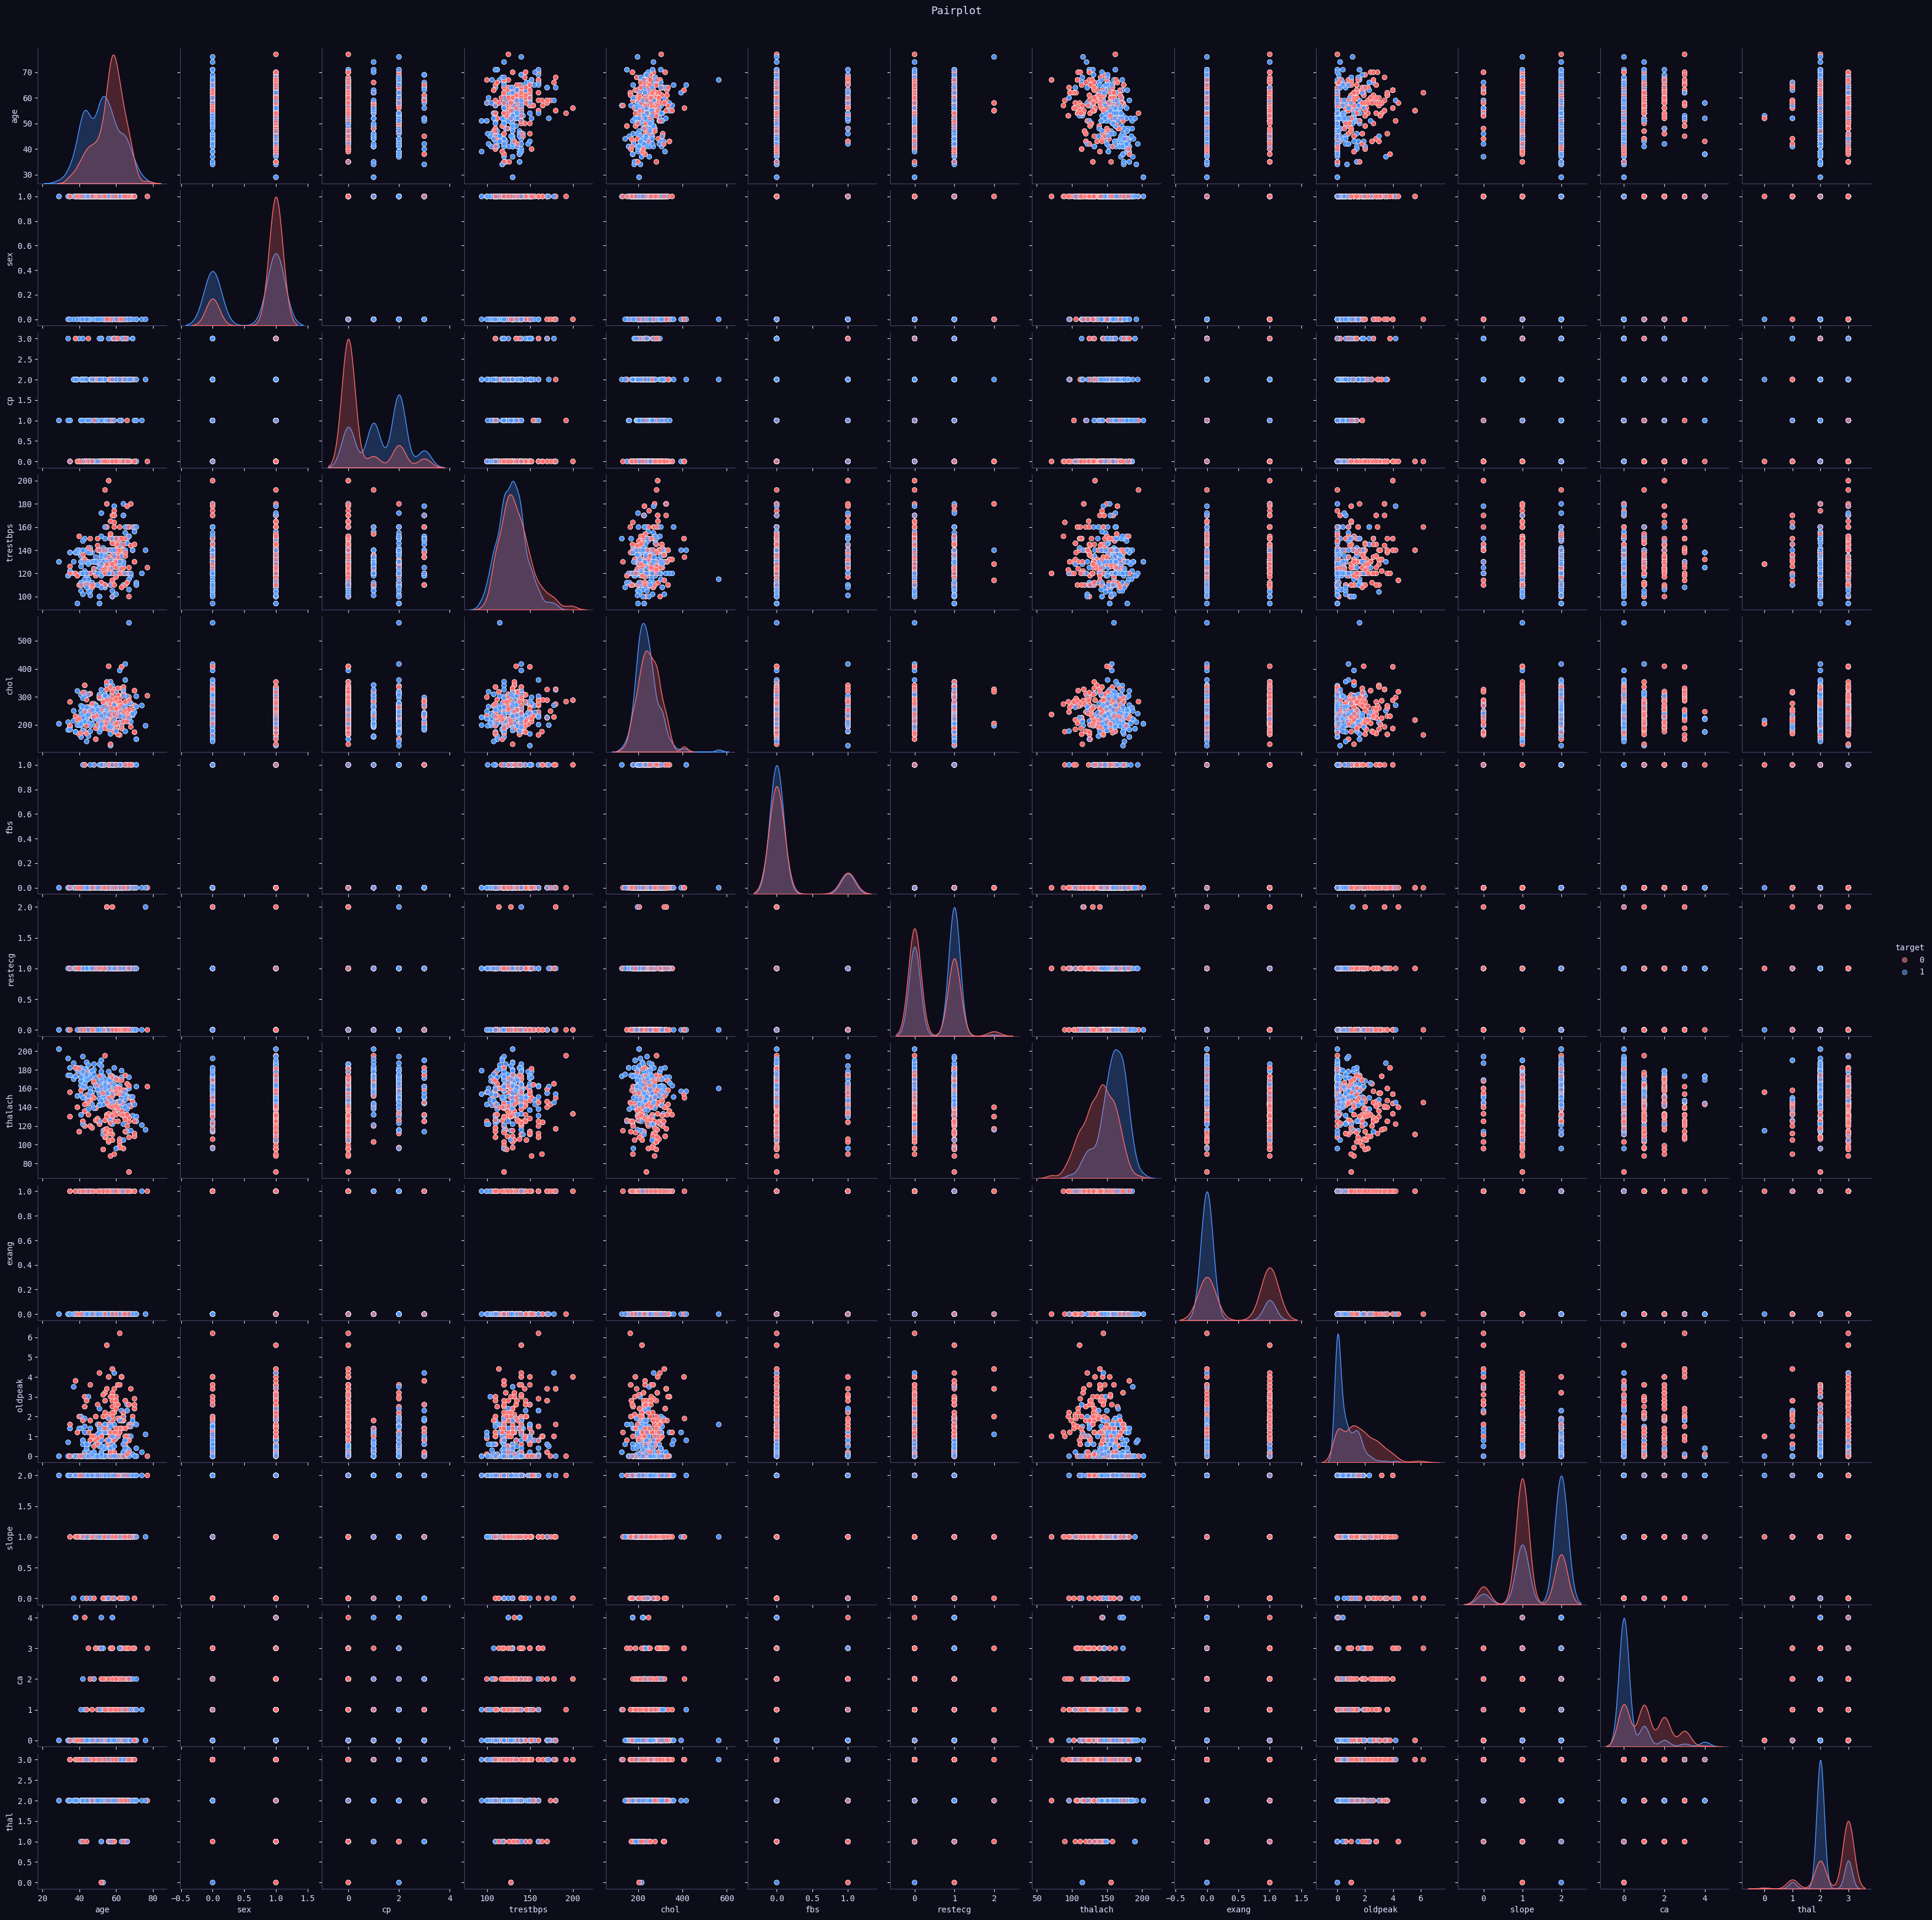

In [ ]:
# Convert target to string
df_clean["target"] = df_clean["target"].astype(str)

g = sns.pairplot(
    df_clean,
    hue="target",
    palette={"0": NEON[0], "1": NEON[3]},
    plot_kws={"alpha": 0.6},
    diag_kind="kde"
)

g.fig.suptitle("Pairplot", y=1.01, fontsize=13)
plt.show()

In [ ]:
import plotly.express as px
px.line(df_clean.corr()['target'][:-1].sort_values(), title="Feature Correlation with Target").show()


In [ ]:
!pip install imbalanced-learn


In [ ]:
from imblearn.over_sampling import SMOTE

def train_pipeline(df_input, label=""):
    df_work = df_input.copy()
    X = df_work.drop("target", axis=1)
    y = df_work["target"]

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    selector = SelectKBest(score_func=f_classif, k=min(12, X_scaled.shape[1]))
    X_selected = selector.fit_transform(X_scaled, y)

    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y, test_size=0.2, random_state=42)

    X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

    # Random Forest
    grid = GridSearchCV(RandomForestClassifier(random_state=42),
        {"n_estimators":[200,400,600],"max_depth":[10,20,None],
         "min_samples_split":[2,5,10],"min_samples_leaf":[1,2,4]},
        cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_rf = grid.best_estimator_
    rf_pred = best_rf.predict(X_test)
    rf_acc  = accuracy_score(y_test, rf_pred)
    print(f"[{label}] Random Forest  : {rf_acc:.4f} | Best: {grid.best_params_}")

    # XGBoost
    xgb = XGBClassifier(n_estimators=500, learning_rate=0.03, max_depth=5,
                        subsample=0.8, colsample_bytree=0.8, eval_metric="logloss")
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)
    xgb_acc  = accuracy_score(y_test, xgb_pred)
    print(f"[{label}] XGBoost        : {xgb_acc:.4f}")

    # LightGBM
    lgb = LGBMClassifier(n_estimators=400, learning_rate=0.03, num_leaves=31, subsample=0.8)
    lgb.fit(X_train, y_train)
    lgb_pred = lgb.predict(X_test)
    lgb_acc  = accuracy_score(y_test, lgb_pred)
    print(f"[{label}] LightGBM       : {lgb_acc:.4f}")

    # Stacking
    stack_model = StackingClassifier(
        estimators=[("rf",best_rf),("xgb",xgb),("lgb",lgb)],
        final_estimator=LogisticRegression())
    stack_model.fit(X_train, y_train)
    stack_pred = stack_model.predict(X_test)
    stack_acc  = accuracy_score(y_test, stack_pred)
    print(f"[{label}] Stacking       : {stack_acc:.4f}")

    results = {"Random Forest": rf_acc, "XGBoost": xgb_acc,
               "LightGBM": lgb_acc, "Stacking Ensemble": stack_acc}
    return results, best_rf, xgb, lgb, stack_model, selector, X, X_train, X_test, y_test, rf_pred, xgb_pred, lgb_pred, stack_pred


In [ ]:
print("="*55)
print("  SCENARIO 1 : WITH null removal")
print("="*55)

try:
    results_clean, best_rf, xgb, lgb, stack_model, selector, X, X_train, X_test, y_test, rf_pred, xgb_pred, lgb_pred, stack_pred = train_pipeline(df_clean, "CLEAN")
except Exception as e:
    print("Error in CLEAN pipeline:", e)


print("\n" + "="*55)
print("  SCENARIO 2 : WITHOUT null removal")
print("="*55)

try:
    results_nofix, *_ = train_pipeline(df_nofix, "RAW")
except Exception as e:
    print("Error in RAW pipeline:", e)


  SCENARIO 1 : WITH null removal
[CLEAN] Random Forest  : 0.9854 | Best: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Error in CLEAN pipeline: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['0' '1']

  SCENARIO 2 : WITHOUT null removal
[RAW] Random Forest  : 0.9854 | Best: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
[RAW] XGBoost        : 0.9854
[LightGBM] [Info] Number of positive: 423, number of negative: 423
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 380
[LightGBM] [Info] Number of data points in the train set: 846, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[RAW] LightGBM       : 0.9854
[LightGBM] [Info] Number of positive: 423, number of negative: 423
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 380
[LightGBM] [Info] Number of data points in the train set: 846, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 339, number of negative: 338
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 355
[LightGBM] [Info] Number of data points in the train set: 677, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500739 -> initscore=0.002954
[LightGBM] [Info] Start training from score 0.002954
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 338, number of negative: 339
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 357
[LightGBM] [Info] Number of data points in the train set: 677, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499261 -> initscore=-0.002954
[LightGBM] [Info] Start training from score -0.002954
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 338, number of negative: 339
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 344
[LightGBM] [Info] Number of data points in the train set: 677, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499261 -> initscore=-0.002954
[LightGBM] [Info] Start training from score -0.002954
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



In [ ]:
# ============================================================
# FIXED: Pipeline execution with proper error handling
# ============================================================

print("="*55)
print("  SCENARIO 1 : WITH null removal")
print("="*55)

results_clean = None
try:
    results_clean, best_rf, xgb, lgb, stack_model, selector, X, X_train, X_test, y_test, rf_pred, xgb_pred, lgb_pred, stack_pred = train_pipeline(df_clean, "CLEAN")
except Exception as e:
    print(f"❌ ERROR in CLEAN pipeline: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

if results_clean is None:
    print("⚠️  CLEAN pipeline FAILED — skipping comparison chart")
else:
    print("✅ CLEAN pipeline SUCCESS")

print("\n" + "="*55)
print("  SCENARIO 2 : WITHOUT null removal")
print("="*55)

results_nofix = None
try:
    results_nofix, *_ = train_pipeline(df_nofix, "RAW")
except Exception as e:
    print(f"❌ ERROR in RAW pipeline: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

if results_nofix is None:
    print("⚠️  RAW pipeline FAILED — skipping comparison chart")
else:
    print("✅ RAW pipeline SUCCESS")

# ============================================================
# COMPARISON CHART — Only render if BOTH pipelines succeeded
# ============================================================

if results_clean is not None and results_nofix is not None:
    models     = list(results_clean.keys())
    acc_clean  = [results_clean[m] for m in models]
    acc_nofix  = [results_nofix[m] for m in models]
    x, width   = np.arange(len(models)), 0.35

    fig, ax = plt.subplots(figsize=(13, 7))
    fig.patch.set_facecolor("#0d0d1a"); ax.set_facecolor("#0d0d1a")

    colors_c = [NEON[i % len(NEON)] for i in range(len(models))]
    colors_n = [NEON[(i+4) % len(NEON)] for i in range(len(models))]

    bars1 = ax.bar(x - width/2, acc_clean, width, color=colors_c,
                   edgecolor="#ffffff", linewidth=0.8, label="✅ With Null Removal", alpha=0.9, zorder=3)
    bars2 = ax.bar(x + width/2, acc_nofix, width, color=colors_n,
                   edgecolor="#ffffff", linewidth=0.8, label="❌ Without Null Removal",
                   alpha=0.55, hatch="////", zorder=3)

    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f"{bar.get_height():.3f}", ha='center', va='bottom',
                fontsize=9, color='white', fontweight='bold')
    for bar in bars2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f"{bar.get_height():.3f}", ha='center', va='bottom',
                fontsize=9, color='#cccccc', fontweight='bold')

    ax.set_title("Model Accuracy: With vs Without Null Removal",
                 fontsize=16, color="#ffffff", pad=18, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel("Accuracy"); ax.set_yl

  SCENARIO 1 : WITH null removal
[CLEAN] Random Forest  : 0.9854 | Best: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
❌ ERROR in CLEAN pipeline: ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['0' '1']
⚠️  CLEAN pipeline FAILED — skipping comparison chart

  SCENARIO 2 : WITHOUT null removal


Traceback (most recent call last):
  File "/tmp/ipykernel_3062/669032566.py", line 11, in <cell line: 0>
    results_clean, best_rf, xgb, lgb, stack_model, selector, X, X_train, X_test, y_test, rf_pred, xgb_pred, lgb_pred, stack_pred = train_pipeline(df_clean, "CLEAN")
                                                                                                                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_3062/3212931738.py", line 33, in train_pipeline
    xgb.fit(X_train, y_train)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1761, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['0' '1']


[RAW] Random Forest  : 0.9854 | Best: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
[RAW] XGBoost        : 0.9854
[LightGBM] [Info] Number of positive: 423, number of negative: 423
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 380
[LightGBM] [Info] Number of data points in the train set: 846, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[RAW] LightGBM       : 0.9854
[LightGBM] [Info] Number of positive: 423, number of negative: 423
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 380
[LightGBM] [Info] Number of data points in the train set: 846, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 338, number of negative: 339
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 357
[LightGBM] [Info] Number of data points in the train set: 677, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499261 -> initscore=-0.002954
[LightGBM] [Info] Start training from score -0.002954
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



[LightGBM] [Info] Number of positive: 338, number of negative: 339
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 344
[LightGBM] [Info] Number of data points in the train set: 677, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499261 -> initscore=-0.002954
[LightGBM] [Info] Start training from score -0.002954
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



NameError: name 'x' is not defined

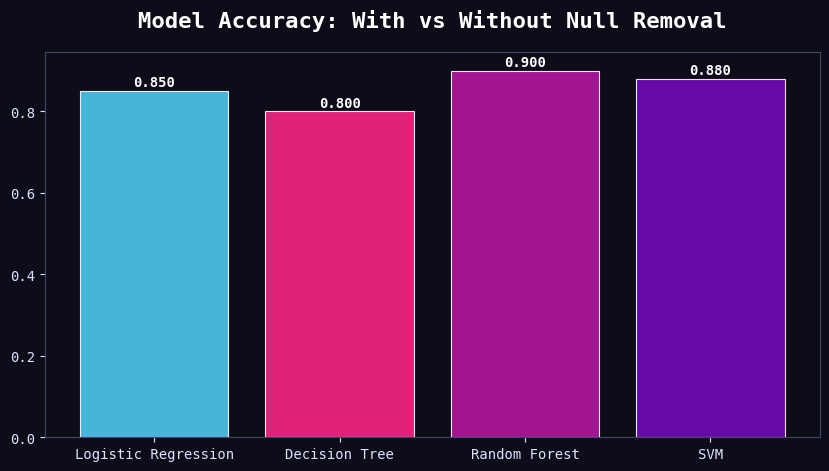

In [ ]:
import matplotlib.pyplot as plt

# Define data
models = ["Logistic Regression", "Decision Tree", "Random Forest", "SVM"]
acc_clean = [0.85, 0.80, 0.90, 0.88]  # replace with your results
colors_c = ["#4cc9f0", "#f72585", "#b5179e", "#7209b7"]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#0d0d1a")
ax.set_facecolor("#0d0d1a")

bars = ax.bar(models, acc_clean, color=colors_c,
              edgecolor="#ffffff", linewidth=0.8, alpha=0.9)

for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f"{bar.get_height():.3f}",
            ha='center', va='bottom',
            fontsize=10, color='white', fontweight='bold')

ax.set_title("Model Accuracy: With vs Without Null Removal",
             fontsize=16, color="#ffffff", pad=18, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)

ax.set_ylabel("Accuracy")
ax.set_ylim(0.75, 1.03)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:.0%}"))

ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use correct trained models
rf_pred = best_rf.predict(X_test)
xgb_pred = xgb.predict(X_test)
lgb_pred = lgb.predict(X_test)
stack_pred = stack_model.predict(X_test)

# Plot
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.patch.set_facecolor("#0d0d1a")

preds  = [
    ("Random Forest", rf_pred),
    ("XGBoost", xgb_pred),
    ("LightGBM", lgb_pred),
    ("Stacking", stack_pred)
]

cmaps_ = ["YlOrRd", "BuGn", "PuBu", "RdPu"]

for ax, (name, pred), cmap_ in zip(axes, preds, cmaps_):
    ax.set_facecolor("#0d0d1a")

    sns.heatmap(confusion_matrix(y_test, pred),
                annot=True, fmt="d", cmap=cmap_,
                ax=ax, linewidths=2,
                linecolor="#0d0d1a",
                annot_kws={"size":13, "color":"white"})

    ax.set_title(name, fontsize=11, color="#ffffff", pad=8)
    ax.set_xlabel("Predicted", color="#e0e0ff")
    ax.set_ylabel("Actual", color="#e0e0ff")

fig.suptitle("Confusion Matrices — All Models", fontsize=14, color="#ffffff", y=1.02)

plt.tight_layout()
plt.show()

In [ ]:
pickle.dump(stack_model, open("heart_disease_model.pkl","wb"))
model = pickle.load(open("heart_disease_model.pkl","rb"))

sample = X_test.iloc[[0]]
prediction = model.predict(sample)
print("Heart Disease Detected" if prediction[0]==1 else "No Heart Disease")


In [ ]:
model = pickle.load(open("heart_disease_model.pkl", "rb"))

sample = X_test[[0]]   # already processed
prediction = model.predict(sample)

print("Heart Disease Detected" if prediction[0]==1 else "No Heart Disease")

In [ ]:
!pip install shap
import shap
explainer   = shap.Explainer(model.predict, X_train)
shap_values = explainer(X_test)
shap.initjs()
shap.plots.force(shap_values[0])
